# Import Libraries

In [ ]:
import os
from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import kruskal
from scipy.stats import mannwhitneyu
import itertools
import seaborn as sns
from scipy import stats
from scipy.stats import friedmanchisquare
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import itertools
from statsmodels.stats.multitest import multipletests

# Load dataset

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive/ISP

Papers	simu.zip


In [ ]:
!unzip /content/drive/MyDrive/ISP/simu.zip -d /content/data

Archive:  /content/drive/MyDrive/ISP/simu.zip
   creating: /content/data/simu/
   creating: /content/data/simu/5_6_8_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._5_6_8_sttc-precision_sign+  
  inflating: /content/data/simu/.DS_Store  
  inflating: /content/data/__MACOSX/simu/._.DS_Store  
   creating: /content/data/simu/5_6_8_sttc-corr_sign+/
  inflating: /content/data/__MACOSX/simu/._5_6_8_sttc-corr_sign+  
   creating: /content/data/simu/5_3_4_sttc-corr/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-corr  
   creating: /content/data/simu/5_3_4_sttc-corr_sign+/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-corr_sign+  
   creating: /content/data/simu/5_3_4_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._5_3_4_sttc-precision_sign+  
   creating: /content/data/simu/6_6_2_sttc-precision_sign+/
  inflating: /content/data/__MACOSX/simu/._6_6_2_sttc-precision_sign+  
   creating: /content/data/simu/6_6_2_sttc-precision/
  inflating: /cont

In [ ]:
print(os.listdir("/content/data/simu"))

['5_6_8_sttc-precision', 'rcc.ipynb', '6_6_2_sttc-precision', '5_6_8_sttc-precision_sign+', 'plotting.ipynb', '6_6_2_sttc-corr_sign+', '5_3_4_sttc-precision_sign+', '6_6_2_sttc-corr', '6_6_2_sttc-precision_sign+', '.DS_Store', '5_3_4_sttc-corr_sign+', '5_6_8_sttc-corr', '5_6_8_sttc-corr_sign+', '5_3_4_sttc-corr', '5_3_4_sttc-precision']


## In the same scan and field

In [ ]:
session, scan, field = 6, 6, 2

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name = f'/content/data/simu/{base}'
print(folder_name)

# task1_file_dir = f'{folder_name}/Task1/{metric}_raw.csv'
# task2_file_dir = f'{folder_name}/Task2/{metric}_raw.csv'
# task3_file_dir = f'{folder_name}/Task3/{metric}_raw.csv'

/content/data/simu/6_6_2_sttc-corr


In [ ]:
task1_folder_dir = f'{folder_name}/Task3/'

In [ ]:
import pandas as pd

metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df.to_csv("combined_dataset.csv", index=False)



print(final_df.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C  0.882422    -0.153560    0.478768  0.366364   
1                  1      W*D*C  0.883398    -0.012323    0.405021  0.231803   
2                  2      W*D*C  0.879492    -0.255139    0.476326  0.698163   
3                  3      W*D*C  0.496484    -0.325830    0.369690  0.486206   
4                  4      W*D*C  0.886328    -0.322735    0.566645  0.174165   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        1.517240  0.244738             0.899219         0.216070  
1        1.828454  0.233570             0.902734         0.200823  
2        3.620841  0.244352             0.901953         0.225818  
3        3.200858  0.694286             0.516016         0.693582  
4        4.068001  0.240721             0.898438         0.223795  


In [ ]:
def classify_variant(model):
    if "W*" in model:
        return "w*"
    elif "W!" in model:
        return "w!"
    else:
        return "w"

final_df["w_variant"] = final_df["model_name"].apply(classify_variant)


In [ ]:
scaler = MinMaxScaler()
final_df["loss"] = scaler.fit_transform(final_df[["loss"]])
final_df['validation_loss'] = scaler.fit_transform(final_df[["validation_loss"]])


In [ ]:
final_df.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant
0,0,W*D*C,0.882422,-0.153560,0.478768,0.366364,1.517240,0.000347,0.899219,0.000379,w*
1,1,W*D*C,0.883398,-0.012323,0.405021,0.231803,1.828454,0.000059,0.902734,0.000039,w*
2,2,W*D*C,0.879492,-0.255139,0.476326,0.698163,3.620841,0.000337,0.901953,0.000597,w*
3,3,W*D*C,0.496484,-0.325830,0.369690,0.486206,3.200858,0.011962,0.516016,0.011049,w*
4,4,W*D*C,0.886328,-0.322735,0.566645,0.174165,4.068001,0.000243,0.898438,0.000552,w*


# Compare only two models

In [ ]:
metrics = ['accuracy', 'assortivity', 'entropy', 'loss', 'modularity', 'smallWorldness', 'validation_accuracy', 'validation_loss']

In [ ]:
def are_models_significantly_different(df, model1, model2, metric):
  res = kruskal(
    df.query(f"model_name == '{model1}'")[metric],
    df.query(f"model_name == '{model2}'")[metric],
  )

  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:

for metric in metrics:
  print(f'{metric} : {are_models_significantly_different(final_df, 'WD*C*', 'W*D*C*', metric)}')

accuracy : (True, np.float64(6.221927767732984e-08))
assortivity : (True, np.float64(9.882703709104151e-08))
entropy : (False, np.float64(0.09893159920140929))
loss : (True, np.float64(6.301848221392254e-08))
modularity : (False, np.float64(0.1298217973765279))
smallWorldness : (True, np.float64(6.301848221392254e-08))
validation_accuracy : (True, np.float64(7.280297034671969e-09))
validation_loss : (True, np.float64(7.326768199477227e-08))


In [ ]:

for metric in metrics:
  print(f'{metric} : {are_models_significantly_different(final_df, 'W*D*C*', 'W!D*C*', metric)}')

accuracy : (False, np.float64(0.7147751024766875))
assortivity : (False, np.float64(0.21338766418298685))
entropy : (False, np.float64(0.15954465937786272))
loss : (False, np.float64(0.5517753193316655))
modularity : (False, np.float64(0.8076561934993339))
smallWorldness : (False, np.float64(0.5338418935166418))
validation_accuracy : (False, np.float64(0.9783690067816353))
validation_loss : (False, np.float64(0.3039952778179324))


In [ ]:

for metric in metrics:
  print(f'{metric} : {are_models_significantly_different(final_df, 'WD*C', 'W!D*C', metric)}')

accuracy : (True, np.float64(4.6421544796598644e-05))
assortivity : (True, np.float64(8.51232841689561e-08))
entropy : (True, np.float64(6.301848221392254e-08))
loss : (True, np.float64(2.0624711744910948e-07))
modularity : (True, np.float64(3.179788366339599e-07))
smallWorldness : (False, np.float64(0.291446604644503))
validation_accuracy : (True, np.float64(0.014682276725430172))
validation_loss : (True, np.float64(2.7544569323063594e-07))


# Compare the effect of w_variant

In [ ]:
def are_w_variants_significantly_different(df, metric):
  res = kruskal(
    df.query("w_variant == 'w'")[metric],
    df.query("w_variant == 'w*'")[metric],
    df.query("w_variant == 'w!'")[metric]
  )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue


In [ ]:
are_w_variants_significantly_different(final_df, "smallWorldness")

(True, np.float64(1.2294143158911865e-10))

In [ ]:
metrics = ['accuracy', 'assortivity', 'entropy', 'loss', 'modularity', 'smallWorldness', 'validation_accuracy', 'validation_loss']

for metric in metrics:
  print(f'{metric} : {are_w_variants_significantly_different(final_df, metric)}')

accuracy : (True, np.float64(3.462512220609324e-30))
assortivity : (True, np.float64(1.496970456086663e-30))
entropy : (True, np.float64(0.0001270569490551874))
loss : (True, np.float64(0.004144275249588796))
modularity : (True, np.float64(0.001405966898648995))
smallWorldness : (True, np.float64(1.2294143158911865e-10))
validation_accuracy : (True, np.float64(1.7714763704587954e-29))
validation_loss : (True, np.float64(0.0035864613331489208))


# Effect of sign constraint on W

In [ ]:
session, scan, field = 6, 6, 2

sign_constraint = True # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name_1 = f'/content/data/simu/{base}'
print(folder_name_1)

/content/data/simu/6_6_2_sttc-corr_sign+


In [ ]:
task1_folder_dir_sign = f'{folder_name_1}/Task3/'
task1_folder_dir_sign

'/content/data/simu/6_6_2_sttc-corr_sign+/Task3/'

In [ ]:
import pandas as pd

metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir_sign, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df_sign = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df_sign.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df_sign.to_csv("combined_dataset_1.csv", index=False)

print(final_df_sign.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C  0.897656    -0.217443    0.249108  0.103939   
1                  1      W*D*C  0.492188    -0.026493    0.211951  0.020969   
2                  2      W*D*C  0.889844    -0.217683    0.408344  0.238586   
3                  3      W*D*C  0.891797    -0.272221    0.371371  0.246958   
4                  4      W*D*C  0.896680    -0.031564    0.407867  0.090989   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        1.475145  0.220963             0.885938         0.289732  
1        0.734272  0.693316             0.491406         0.693759  
2        2.669710  0.254818             0.874609         0.343156  
3        1.660208  0.246520             0.890625         0.259340  
4        1.804698  0.225258             0.896094         0.212548  


In [ ]:
scaler = MinMaxScaler()
final_df_sign["w_variant"] = final_df_sign["model_name"].apply(classify_variant)
final_df_sign["loss"] = scaler.fit_transform(final_df_sign[["loss"]])
final_df_sign['validation_loss'] = scaler.fit_transform(final_df_sign[["validation_loss"]])

In [ ]:
final_df_sign.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant
0,0,W*D*C,0.897656,-0.217443,0.249108,0.103939,1.475145,0.000767,0.885938,0.006235,w*
1,1,W*D*C,0.492188,-0.026493,0.211951,0.020969,0.734272,0.036013,0.491406,0.035912,w*
2,2,W*D*C,0.889844,-0.217683,0.408344,0.238586,2.669710,0.003293,0.874609,0.010159,w*
3,3,W*D*C,0.891797,-0.272221,0.371371,0.246958,1.660208,0.002674,0.890625,0.004002,w*
4,4,W*D*C,0.896680,-0.031564,0.407867,0.090989,1.804698,0.001088,0.896094,0.000565,w*


In [ ]:
non_biological_metrics = ['accuracy', 'loss', 'validation_accuracy', 'validation_loss']
biological_metrics = ['assortivity', 'entropy', 'modularity', 'smallWorldness']

In [ ]:
final_df['sign'] = False
final_df_sign['sign'] = True

In [ ]:
combined_df_sign = pd.concat([final_df, final_df_sign], ignore_index=True)

combined_df_sign = combined_df_sign.sort_values(["simulation_number", "model_name"]).reset_index(drop=True)

combined_df_sign.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign
0,0,W,0.498047,-0.012248,0.088363,5.717292,0.990225,0.326478,0.516016,0.282245,w,False
1,0,W,0.498242,NaN,NaN,NaN,NaN,NaN,0.508594,NaN,w,True
2,0,W!D*C,0.886133,-0.168249,0.471167,1.978912,2.651141,0.000381,0.900000,0.000443,w!,False
3,0,W!D*C,0.892383,-0.150520,0.504912,0.155485,3.124914,0.002534,0.885547,0.006634,w!,True
4,0,W!D*C*,0.882422,-0.055293,0.091938,0.354225,1.000876,0.385494,0.898828,0.340735,w!,False


In [ ]:
combined_df_sign.shape

(440, 12)

In [ ]:
def is_sign_constraint_significantly_different(df, metric):
  res = kruskal(
    df.query("sign == True")[metric],
    df.query("sign == False")[metric]
    )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
for metric in non_biological_metrics:
    print(f'W - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[combined_df_sign['w_variant'] == 'w'], metric)}')
    print(f'W* - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[combined_df_sign['w_variant'] == 'w*'], metric)}')
    print(f'W! - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[combined_df_sign['w_variant'] == 'w!'], metric)}\n')

W - accuracy : (False, np.float64(nan))
W* - accuracy : (False, np.float64(nan))
W! - accuracy : (False, np.float64(nan))

W - loss : (False, np.float64(nan))
W* - loss : (False, np.float64(nan))
W! - loss : (False, np.float64(nan))

W - validation_accuracy : (False, np.float64(nan))
W* - validation_accuracy : (False, np.float64(nan))
W! - validation_accuracy : (False, np.float64(nan))

W - validation_loss : (False, np.float64(nan))
W* - validation_loss : (False, np.float64(nan))
W! - validation_loss : (False, np.float64(nan))



/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-in

#### Biological Metrics

In [ ]:
for metric in biological_metrics:
  print(f'W* - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[(combined_df_sign["w_variant"] == "w*")], metric)}')
  print(f'W! - {metric} : {is_sign_constraint_significantly_different(combined_df_sign[(combined_df_sign["w_variant"] == "w!")], metric)}')

W* - assortivity : (False, np.float64(nan))
W! - assortivity : (False, np.float64(nan))
W* - entropy : (False, np.float64(nan))
W! - entropy : (False, np.float64(nan))
W* - modularity : (False, np.float64(nan))
W! - modularity : (False, np.float64(nan))
W* - smallWorldness : (False, np.float64(nan))
W! - smallWorldness : (False, np.float64(nan))


/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-input-2929028126.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  res = kruskal(
/tmp/ipython-in

# Correlation matrix vs Presicion matrix effect on W




In [ ]:
session, scan, field = 6, 6, 2

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = True # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name_2 = f'/content/data/simu/{base}'
print(folder_name_2)

/content/data/simu/6_6_2_sttc-precision


In [ ]:
task1_folder_dir_precision = f'{folder_name_2}/Task3/'
task1_folder_dir_precision

'/content/data/simu/6_6_2_sttc-precision/Task3/'

In [ ]:
import pandas as pd

metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir_precision, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df_precision = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df_precision.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df_precision.to_csv("combined_dataset_1.csv", index=False)

print(final_df_precision.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C  0.892187     0.277983    0.291187  0.381482   
1                  1      W*D*C  0.887500    -0.247286    0.499983  0.453397   
2                  2      W*D*C  0.891406    -0.252884    0.498773  1.630814   
3                  3      W*D*C  0.885742    -0.123081    0.469710  0.290327   
4                  4      W*D*C  0.891016    -0.198076    0.466086  0.338831   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        1.352259  0.229359             0.901563         0.199597  
1        2.851502  0.241479             0.901563         0.212835  
2        3.031601  0.248088             0.903906         0.218552  
3        1.754804  0.234853             0.901953         0.217778  
4        2.965212  0.232054             0.906250         0.212010  


In [ ]:
def classify_variant(model):
    if "W*" in model:
        return "w*"
    elif "W!" in model:
        return "w!"
    else:
        return "w"

final_df_precision["w_variant"] = final_df_precision["model_name"].apply(classify_variant)

In [ ]:
scaler = MinMaxScaler()
final_df_precision["loss"] = scaler.fit_transform(final_df_precision[["loss"]])
final_df_precision['validation_loss'] = scaler.fit_transform(final_df_precision[["validation_loss"]])

In [ ]:
final_df_precision.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant
0,0,W*D*C,0.892187,0.277983,0.291187,0.381482,1.352259,0.000084,0.901563,0.000000,w*
1,1,W*D*C,0.887500,-0.247286,0.499983,0.453397,2.851502,0.000391,0.901563,0.000306,w*
2,2,W*D*C,0.891406,-0.252884,0.498773,1.630814,3.031601,0.000559,0.903906,0.000438,w*
3,3,W*D*C,0.885742,-0.123081,0.469710,0.290327,1.754804,0.000223,0.901953,0.000421,w*
4,4,W*D*C,0.891016,-0.198076,0.466086,0.338831,2.965212,0.000152,0.906250,0.000287,w*


In [ ]:
final_df['matrix'] = 'sttc'
final_df_precision['matrix'] = 'precision'

combined_df_matrix = pd.concat([final_df, final_df_precision], ignore_index=True)

combined_df_matrix = combined_df_matrix.sort_values(["simulation_number", "model_name"]).reset_index(drop=True)

combined_df_matrix.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign,matrix
0,0,W,0.498047,-0.012248,0.088363,5.717292,0.990225,0.326478,0.516016,0.282245,w,False,sttc
1,0,W,0.504883,-0.016198,0.086552,5.713612,0.983992,0.320809,0.501172,0.292967,w,NaN,precision
2,0,W!D*C,0.886133,-0.168249,0.471167,1.978912,2.651141,0.000381,0.900000,0.000443,w!,False,sttc
3,0,W!D*C,0.889648,-0.229742,0.500371,1.141075,2.517536,0.000500,0.906250,0.000359,w!,NaN,precision
4,0,W!D*C*,0.882422,-0.055293,0.091938,0.354225,1.000876,0.385494,0.898828,0.340735,w!,False,sttc


In [ ]:
def is_matrix_variant_significantly_different(df, metric):
  res = kruskal(
    df.query("matrix == 'sttc'")[metric],
    df.query("matrix == 'precision'")[metric]
    )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
def how_matrix_variants_are_different(df, metric, variant):
    groups = df["matrix"].unique()
    pairs = list(itertools.combinations(groups, 2))

    print(f"\n------ {metric} --- {variant} ------")
    for g1, g2 in pairs:
        x = df.query("matrix == @g1")[metric].dropna().astype(float)
        y = df.query("matrix == @g2")[metric].dropna().astype(float)

        u, p = mannwhitneyu(x, y, alternative='two-sided')

        median_x, median_y = np.median(x), np.median(y)
        mean_x, mean_y = np.mean(x), np.mean(y)

        n1, n2 = len(x), len(y)
        prob_superiority = u / (n1 * n2)  # P(X > Y)

        direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

        signif = "TRUE" if p < 0.05 else "FALSE"
        print(
            f"{g1} vs {g2}: {signif}, "
            f"U={u:.1f}, p={p:.3g}, "
            f"Median({g1})={median_x:.3f}, Median({g2})={median_y:.3f}, "
            f"Mean({g1})={mean_x:.3f}, Mean({g2})={mean_y:.3f}, "
            f"{g1} {direction} {g2}, P(X>Y)={prob_superiority:.2f}"
        )
    print("\n")


In [ ]:
for metric in metrics:
    print(f'W - {metric} : {is_matrix_variant_significantly_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w'], metric)}')
    print(f'W* - {metric} : {is_matrix_variant_significantly_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w*'], metric)}')
    print(f'W! - {metric} : {is_matrix_variant_significantly_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w!'], metric)}\n')

W - accuracy : (True, np.float64(5.836250249879542e-20))
W* - accuracy : (True, np.float64(5.92546486199816e-05))
W! - accuracy : (False, np.float64(0.12124952187456824))

W - assortivity : (False, np.float64(0.7931731731940068))
W* - assortivity : (False, np.float64(0.6143532071157063))
W! - assortivity : (False, np.float64(0.16881601673732838))

W - entropy : (False, np.float64(0.9525501696317236))
W* - entropy : (False, np.float64(0.4466256339369935))
W! - entropy : (False, np.float64(0.4189234409463921))

W - loss : (False, np.float64(0.05289706179729983))
W* - loss : (False, np.float64(0.8645531935135563))
W! - loss : (False, np.float64(0.8436221249617545))

W - modularity : (False, np.float64(0.2347415134530477))
W* - modularity : (False, np.float64(0.4010305099987753))
W! - modularity : (False, np.float64(0.6033317722918787))

W - smallWorldness : (False, np.float64(0.9185395091955488))
W* - smallWorldness : (False, np.float64(0.15189259242784883))
W! - smallWorldness : (False, 

In [ ]:
for metric in metrics:
  how_matrix_variants_are_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w'], metric, 'w')
  how_matrix_variants_are_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w*'], metric, 'w*')
  how_matrix_variants_are_different(combined_df_matrix[combined_df_matrix['w_variant'] == 'w!'], metric, 'w!')


------ accuracy --- w ------
sttc vs precision: TRUE, U=2281.5, p=5.89e-20, Median(sttc)=0.500, Median(precision)=0.507, Mean(sttc)=0.552, Mean(precision)=0.558, sttc < precision, P(X>Y)=0.16



------ accuracy --- w* ------
sttc vs precision: TRUE, U=1035.0, p=5.99e-05, Median(sttc)=0.882, Median(precision)=0.886, Mean(sttc)=0.869, Mean(precision)=0.831, sttc < precision, P(X>Y)=0.29



------ accuracy --- w! ------
sttc vs precision: FALSE, U=639.0, p=0.122, Median(sttc)=0.883, Median(precision)=0.886, Mean(sttc)=0.857, Mean(precision)=0.792, sttc < precision, P(X>Y)=0.40



------ assortivity --- w ------
sttc vs precision: FALSE, U=7059.0, p=0.794, Median(sttc)=-0.001, Median(precision)=-0.001, Mean(sttc)=0.111, Mean(precision)=0.099, sttc > precision, P(X>Y)=0.49



------ assortivity --- w* ------
sttc vs precision: FALSE, U=1896.0, p=0.616, Median(sttc)=-0.061, Median(precision)=-0.106, Mean(sttc)=-0.092, Mean(precision)=-0.097, sttc > precision, P(X>Y)=0.53



------ assortivi

# Compare the effect of neuron count

In [ ]:
session, scan, field = 5, 6, 8

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name_2 = f'/content/data/simu/{base}'
print(folder_name_2)

/content/data/simu/5_6_8_sttc-corr


In [ ]:
task1_folder_dir_568 = f'{folder_name_2}/Task3/'
task1_folder_dir_568

'/content/data/simu/5_6_8_sttc-corr/Task3/'

In [ ]:
import pandas as pd

metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir_568, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df_568 = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df_568.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df_568.to_csv("combined_dataset_1.csv", index=False)

print(final_df_568.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C  0.885938    -0.210402    0.518634  0.706305   
1                  1      W*D*C  0.889844    -0.160553    0.544673  0.884490   
2                  2      W*D*C  0.490430    -0.340330    0.359063  0.857050   
3                  3      W*D*C  0.891992    -0.192482    0.518206  0.752329   
4                  4      W*D*C  0.890039    -0.223986    0.502853  1.089219   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        3.399565  0.253046             0.894922         0.226034  
1        3.530977  0.245675             0.893359         0.229731  
2        3.265752  0.694688             0.494922         0.694144  
3        3.396642  0.235078             0.893359         0.234066  
4        3.152979  0.241196             0.892578         0.219307  


In [ ]:
session, scan, field = 5, 3, 4

sign_constraint = False # Whether to apply a sign constraint on the weights
use_only_sttc = False # Whether to use only STTC for the bio weights
use_precison_matrix = False # Whether to use the precision matrix for the bio weights

base = f'{session}_{scan}_{field}_sttc'
if not use_only_sttc:
    base += '-precision' if use_precison_matrix else '-corr'
if sign_constraint:
    base += '_sign+'
folder_name_2 = f'/content/data/simu/{base}'
print(folder_name_2)

/content/data/simu/5_3_4_sttc-corr


In [ ]:
task1_folder_dir_534 = f'{folder_name_2}/Task3/'
task1_folder_dir_534

'/content/data/simu/5_3_4_sttc-corr/Task3/'

In [ ]:
import pandas as pd

metrics_dic = {
    "Accuracy_raw.csv": "accuracy",
    "Assortativity_raw.csv": "assortivity",
    "Modularity_raw.csv": "modularity",
    "Entropy_raw.csv": "entropy",
    "SmallWorldness_raw.csv": "smallWorldness",
    "Loss_raw.csv" : "loss",
    "Validation_Accuracy_raw.csv" : "validation_accuracy",
    "Validation_Loss_raw.csv" : "validation_loss"
}

dfs = []

for file, metric_name in metrics_dic.items():
    file_path = os.path.join(task1_folder_dir_534, file)
    # Read CSV (first column is simulation number / index)
    df = pd.read_csv(file_path, index_col=0)

    # Convert from wide format to long format
    df_long = df.reset_index().melt(
        id_vars=df.index.name,  # simulation number
        var_name="model_name",
        value_name=metric_name
    )

    dfs.append(df_long)

# Merge all metrics on simulation_number + model_name
from functools import reduce
final_df_534 = reduce(lambda left, right: pd.merge(left, right, on=[df.index.name, "model_name"]), dfs)

# Rename index column to simulation_number
final_df_534.rename(columns={df.index.name: "simulation_number"}, inplace=True)

# Save to CSV
final_df_534.to_csv("combined_dataset_1.csv", index=False)

print(final_df_534.head())

   simulation_number model_name  accuracy  assortivity  modularity   entropy  \
0                  0      W*D*C  0.890820    -0.169977    0.520232  2.340677   
1                  1      W*D*C  0.887891    -0.148199    0.371741  2.214114   
2                  2      W*D*C  0.889648    -0.217397    0.429709  2.527461   
3                  3      W*D*C  0.887500    -0.185414    0.563913  2.230996   
4                  4      W*D*C  0.511914    -0.272273    0.240181  1.846657   

   smallWorldness      loss  validation_accuracy  validation_loss  
0        2.331799  0.235444             0.899219         0.216648  
1        1.856308  0.235525             0.893359         0.236181  
2        1.422993  0.224989             0.902734         0.212289  
3        2.297606  0.242748             0.895312         0.235652  
4        1.360858  0.692837             0.489844         0.691311  


In [ ]:
scaler = MinMaxScaler()
final_df_568["loss"] = scaler.fit_transform(final_df[["loss"]])
final_df_568['validation_loss'] = scaler.fit_transform(final_df[["validation_loss"]])
final_df_534["loss"] = scaler.fit_transform(final_df[["loss"]])
final_df_534['validation_loss'] = scaler.fit_transform(final_df[["validation_loss"]])

In [ ]:
final_df['neuron'] = 312
final_df_568['neuron'] = 160
final_df_534['neuron'] = 70

combined_df_neuron = pd.concat([final_df, final_df_568, final_df_534], ignore_index=True)

combined_df_neuron = combined_df_neuron.sort_values(["simulation_number", "model_name"]).reset_index(drop=True)

combined_df_neuron.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign,matrix,neuron
0,0,W,0.498047,-0.012248,0.088363,5.717292,0.990225,0.326478,0.516016,0.282245,w,False,sttc,312
1,0,W,0.488672,0.023252,0.127468,5.739349,0.931357,0.326478,0.494922,0.282245,NaN,NaN,NaN,160
2,0,W,0.508789,0.035549,0.181225,0.767697,0.763822,0.326478,0.510156,0.282245,NaN,NaN,NaN,70
3,0,W!D*C,0.886133,-0.168249,0.471167,1.978912,2.651141,0.000381,0.900000,0.000443,w!,False,sttc,312
4,0,W!D*C,0.888477,-0.228034,0.429109,0.978769,2.579021,0.000381,0.893750,0.000443,NaN,NaN,NaN,160


In [ ]:
def is_neuron_count_significantly_different(df, metric):
  res = kruskal(
    df.query("neuron == 312")[metric],
    df.query("neuron == 160")[metric],
    df.query("neuron == 70")[metric]
    )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
def how_neuron_count_is_different(df, metric, variant):
  groups = df["neuron"].unique()
  pairs = list(itertools.combinations(groups, 2))

  print(f"\n------ {metric}--- {variant} ------")
  for g1, g2 in pairs:
      x = df.query("neuron == @g1")[metric].dropna().astype(float)
      y = df.query("neuron == @g2")[metric].dropna().astype(float)

      u, p = mannwhitneyu(x, y, alternative='two-sided')

      median_x, median_y = np.median(x), np.median(y)
      mean_x, mean_y = np.mean(x), np.mean(y)

      n1, n2 = len(x), len(y)
      prob_superiority = u / (n1 * n2)  # P(X > Y)

      direction = ">" if median_x > median_y else "<" if median_x < median_y else "="

      signif = "TRUE" if p < 0.05 else "FALSE"
      print(
            f"{g1} vs {g2}: {signif}, "
            f"U={u:.1f}, p={p:.3g}, "
            f"Median({g1})={median_x:.3f}, Median({g2})={median_y:.3f}, "
            f"Mean({g1})={mean_x:.3f}, Mean({g2})={mean_y:.3f}, "
            f"{g1} {direction} {g2}, P(X>Y)={prob_superiority:.2f}"
        )
  print("\n")

In [ ]:
for metric in metrics:
  print(f'{metric} : {is_neuron_count_significantly_different(combined_df_neuron, metric)}')

accuracy : (True, np.float64(6.101281157983063e-08))
assortivity : (True, np.float64(7.071719915241981e-05))
entropy : (True, np.float64(7.743711132808247e-28))
loss : (False, np.float64(1.0))
modularity : (True, np.float64(3.8617928159493855e-29))
smallWorldness : (True, np.float64(2.8898209636515285e-35))
validation_accuracy : (True, np.float64(7.11879543996051e-25))
validation_loss : (False, np.float64(1.0))


In [ ]:
for metric in metrics:
  how_neuron_count_is_different(combined_df_neuron, metric, 'neuron')


------ accuracy--- neuron ------
312 vs 160: TRUE, U=27115.0, p=0.0289, Median(312)=0.848, Median(160)=0.493, Mean(312)=0.694, Mean(160)=0.677, 312 > 160, P(X>Y)=0.56
312 vs 70: TRUE, U=16732.0, p=2.15e-08, Median(312)=0.848, Median(70)=0.865, Mean(312)=0.694, Mean(70)=0.699, 312 < 70, P(X>Y)=0.35
160 vs 70: TRUE, U=18560.5, p=2.35e-05, Median(160)=0.493, Median(70)=0.865, Mean(160)=0.677, Mean(70)=0.699, 160 < 70, P(X>Y)=0.38



------ assortivity--- neuron ------
312 vs 160: FALSE, U=24827.0, p=0.639, Median(312)=-0.017, Median(160)=-0.023, Mean(312)=0.017, Mean(160)=-0.004, 312 > 160, P(X>Y)=0.51
312 vs 70: TRUE, U=29293.0, p=0.000134, Median(312)=-0.017, Median(70)=-0.054, Mean(312)=0.017, Mean(70)=-0.031, 312 > 70, P(X>Y)=0.61
160 vs 70: TRUE, U=29171.0, p=0.000194, Median(160)=-0.023, Median(70)=-0.054, Mean(160)=-0.004, Mean(70)=-0.031, 160 > 70, P(X>Y)=0.60



------ entropy--- neuron ------
312 vs 160: TRUE, U=18400.0, p=1.37e-05, Median(312)=0.367, Median(160)=0.744, Mean(31

# Compare the effect of d_variant

In [ ]:
def classify_d_variant(model):
    if "D*" in model:
        return "d*"
    elif "D" in model:
        return "d"
    else:
        return "nan"

final_df["d_variant"] = final_df["model_name"].apply(classify_d_variant)

In [ ]:
final_df.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign,matrix,neuron,d_variant
0,0,W*D*C,0.882422,-0.153560,0.478768,0.366364,1.517240,0.000347,0.899219,0.000379,w*,False,sttc,312,d*
1,1,W*D*C,0.883398,-0.012323,0.405021,0.231803,1.828454,0.000059,0.902734,0.000039,w*,False,sttc,312,d*
2,2,W*D*C,0.879492,-0.255139,0.476326,0.698163,3.620841,0.000337,0.901953,0.000597,w*,False,sttc,312,d*
3,3,W*D*C,0.496484,-0.325830,0.369690,0.486206,3.200858,0.011962,0.516016,0.011049,w*,False,sttc,312,d*
4,4,W*D*C,0.886328,-0.322735,0.566645,0.174165,4.068001,0.000243,0.898438,0.000552,w*,False,sttc,312,d*


In [ ]:
def are_d_variants_significantly_different(df, metric):
  res = kruskal(
    df.query("d_variant == 'd*'")[metric],
    df.query("d_variant == 'd'")[metric],
    df.query("d_variant == 'nan'")[metric]
  )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
for metric in metrics:
  print(f'{metric} : {are_d_variants_significantly_different(final_df, metric)}')

accuracy : (True, np.float64(1.8496306755541448e-07))
assortivity : (True, np.float64(1.7473899883330844e-06))
entropy : (True, np.float64(5.023075047710995e-15))
loss : (True, np.float64(4.337194703254315e-09))
modularity : (True, np.float64(3.975185136913228e-07))
smallWorldness : (True, np.float64(0.00443747663549945))
validation_accuracy : (True, np.float64(2.9051068752665354e-10))
validation_loss : (True, np.float64(2.7545936891603933e-09))


# Compare the effect of c_variant

In [ ]:
def classify_c_variant(model):
    if "C*" in model:
        return "c*"
    elif "C" in model:
        return "c"
    else:
        return "nan"

final_df["c_variant"] = final_df["model_name"].apply(classify_c_variant)

In [ ]:
final_df.head()

,simulation_number,model_name,accuracy,assortivity,modularity,entropy,smallWorldness,loss,validation_accuracy,validation_loss,w_variant,sign,matrix,neuron,d_variant,c_variant
0,0,W*D*C,0.882422,-0.153560,0.478768,0.366364,1.517240,0.000347,0.899219,0.000379,w*,False,sttc,312,d*,c
1,1,W*D*C,0.883398,-0.012323,0.405021,0.231803,1.828454,0.000059,0.902734,0.000039,w*,False,sttc,312,d*,c
2,2,W*D*C,0.879492,-0.255139,0.476326,0.698163,3.620841,0.000337,0.901953,0.000597,w*,False,sttc,312,d*,c
3,3,W*D*C,0.496484,-0.325830,0.369690,0.486206,3.200858,0.011962,0.516016,0.011049,w*,False,sttc,312,d*,c
4,4,W*D*C,0.886328,-0.322735,0.566645,0.174165,4.068001,0.000243,0.898438,0.000552,w*,False,sttc,312,d*,c


In [ ]:
def are_c_variants_significantly_different(df, metric):
  res = kruskal(
    df.query("c_variant == 'c*'")[metric],
    df.query("c_variant == 'c'")[metric],
    df.query("c_variant == 'nan'")[metric]
  )
  if res.pvalue < 0.05:
    return True, res.pvalue
  else:
    return False, res.pvalue

In [ ]:
for metric in metrics:
  print(f'{metric} : {are_c_variants_significantly_different(final_df, metric)}')

accuracy : (True, np.float64(3.409342304620214e-15))
assortivity : (True, np.float64(5.039610152116296e-08))
entropy : (True, np.float64(3.325812427970057e-13))
loss : (True, np.float64(5.4298502668430066e-36))
modularity : (True, np.float64(1.778737789082609e-35))
smallWorldness : (True, np.float64(9.518589265186726e-37))
validation_accuracy : (True, np.float64(7.224114218367491e-17))
validation_loss : (True, np.float64(5.4298502668430066e-36))


## Non parametric ANOVA test

In [ ]:
def simple_effects_generic(df, metric, focus_factor, within, alpha=0.05, correction='holm', mw_method='auto'):
    """
    Generic simple-effects tester.
    For each unique combination of factors in `within`, tests the effect of `focus_factor`
    on `metric` using Kruskal–Wallis (omnibus) and Mann–Whitney pairwise (posthoc).

    Example:
      simple_effects_generic(df, 'accuracy', 'w_variant', ['d_variant', 'c_variant'])
      simple_effects_generic(df, 'accuracy', 'd_variant', ['w_variant', 'c_variant'])
      simple_effects_generic(df, 'accuracy', 'c_variant', ['w_variant', 'd_variant'])
    """

    records_omni = []
    records_pairs = []

    cells = (
        df[within].dropna().drop_duplicates().sort_values(within)
        .itertuples(index=False, name=None)
    )

    for combo in cells:
        # Build a filtering condition for the current cell
        query_parts = [f"{col} == @{col}" for col in within]
        sub = df.query(" and ".join(query_parts), local_dict=dict(zip(within, combo)))
        sub = sub[[focus_factor, metric]].dropna()

        if sub.empty:
            continue

        # Group by the focus factor
        groups = {g: vals[metric].astype(float).to_numpy() for g, vals in sub.groupby(focus_factor)}
        levels = sorted(groups.keys(), key=lambda z: str(z))

        if len(levels) >= 2:
            samples = [groups[l] for l in levels]
            H, p_omni = kruskal(*samples)
        else:
            H, p_omni = np.nan, np.nan

        # Record omnibus results
        records_omni.append({
            **dict(zip(within, combo)),
            'focus_factor': focus_factor,
            'levels': levels,
            'H': H,
            'p_omni': p_omni,
            'n_by_level': {l: len(groups[l]) for l in levels},
            'median_by_level': {l: np.median(groups[l]) for l in levels},
            'mean_by_level': {l: np.mean(groups[l]) for l in levels},
        })

        # Pairwise comparisons
        if len(levels) == 2 or (len(levels) > 2 and not np.isnan(p_omni) and p_omni < alpha):
            for (l1, l2) in itertools.combinations(levels, 2):
                x, y = groups[l1], groups[l2]
                u, p = mannwhitneyu(x, y, alternative='two-sided', method=mw_method)
                records_pairs.append({
                    **dict(zip(within, combo)),
                    'focus_factor': focus_factor,
                    'l1': l1, 'l2': l2,
                    'U': u, 'p_raw': p,
                    'n1': len(x), 'n2': len(y),
                    'median1': np.median(x), 'median2': np.median(y),
                    'mean1': np.mean(x), 'mean2': np.mean(y)
                })

    # Holm correction across all pairwise tests
    if records_pairs:
        pvals = [r['p_raw'] for r in records_pairs]
        reject, p_adj, _, _ = multipletests(pvals, method=correction, alpha=alpha)
        for i, r in enumerate(records_pairs):
            r['p_adj'] = p_adj[i]
            r['significant'] = bool(reject[i])

    df_omni = pd.DataFrame.from_records(records_omni)
    df_pairs = pd.DataFrame.from_records(records_pairs)

    # Pretty print
    for _, row in df_omni.iterrows():
        cell_desc = ", ".join([f"{k}={row[k]}" for k in within])
        print(f"\n=== {cell_desc} ===")
        if len(row['levels']) >= 2:
            print(f"Kruskal–Wallis across {focus_factor}: H={row['H']:.3f}, p={row['p_omni']:.3g}")
            print("Group sizes & medians:")
            for l in row['levels']:
                print(f"  {focus_factor}={l:<10} n={row['n_by_level'][l]:<4} median={row['median_by_level'][l]:.4g} mean={row['mean_by_level'][l]:.4g}")
        else:
            l = row['levels'][0]
            print(f"Only one {focus_factor} level present: {l}")
            print(f"  n={row['n_by_level'][l]} median={row['median_by_level'][l]:.4g} mean={row['mean_by_level'][l]:.4g}")
            continue

        # Correctly construct the query string for sub_pairs
        query_parts_subpairs = [f"{k} == @row['{k}']" for k in within]
        # sub_pairs = df_pairs.query(" and ".join(query_parts_subpairs), local_dict={'row': row})
        if not df_pairs.empty:
          mask = np.ones(len(df_pairs), dtype=bool)
          for k in within:
              mask &= (df_pairs[k] == row[k])
          sub_pairs = df_pairs[mask]
        else:
            sub_pairs = df_pairs


        if not sub_pairs.empty:
            print("Pairwise Mann–Whitney (Holm-corrected):")
            for _, r2 in sub_pairs.iterrows():
                direction = ">" if r2['median1'] > r2['median2'] else "<" if r2['median1'] < r2['median2'] else "="
                print(f"  {r2['l1']} vs {r2['l2']}: U={r2['U']:.1f}, p_raw={r2['p_raw']:.3g}, p_adj={r2['p_adj']:.3g}, sig={'YES' if r2['significant'] else 'no'}, "
                      f"Median: {r2['l1']} {r2['median1']:.4g} {direction} {r2['l2']} {r2['median2']:.4g}")

    print("\nDone.")
    return df_omni, df_pairs

In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm

def rank_based_anova(df, metric):
    d = df.dropna(subset=[metric, 'w_variant','d_variant','c_variant']).copy()
    d['ranked'] = d[metric].rank(method='average')

    # Fit model on ranks
    model = ols('ranked ~ C(w_variant) * C(d_variant) * C(c_variant)', data=d).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    return anova_table

anova_results = rank_based_anova(final_df, 'smallWorldness')
anova_results


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),2.082472e-09,2.0,2.989873e-12,1.000000e+00
C(d_variant),7.338253e+02,1.0,2.107154e+00,1.486726e-01
C(c_variant),6.185215e-09,1.0,1.776063e-11,9.999966e-01
C(w_variant):C(d_variant),3.795273e+04,2.0,5.448998e+01,1.438698e-18
C(w_variant):C(c_variant),2.855685e+01,2.0,4.100000e-02,8.398087e-01
C(d_variant):C(c_variant),1.005196e+05,1.0,2.886384e+02,5.895869e-37
C(w_variant):C(d_variant):C(c_variant),3.313405e+04,2.0,4.757163e+01,9.036636e-17
Residual,5.293465e+04,152.0,NaN,NaN


<Axes: xlabel='w_variant', ylabel='smallWorldness'>

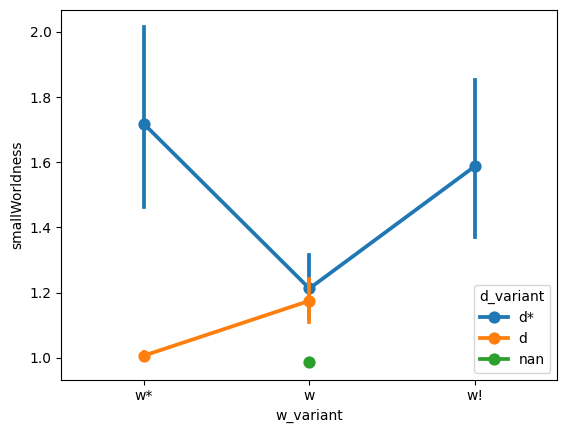

In [ ]:
sns.pointplot(x='w_variant', y='smallWorldness', hue='d_variant', data=final_df)

<Axes: xlabel='w_variant', ylabel='smallWorldness'>

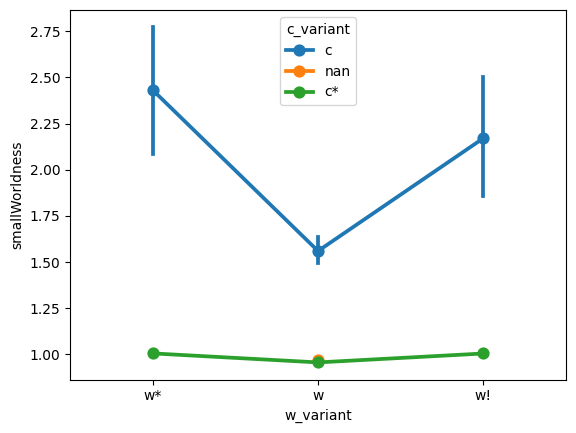

In [ ]:
sns.pointplot(x='w_variant', y='smallWorldness', hue='c_variant', data=final_df)

<Axes: xlabel='d_variant', ylabel='smallWorldness'>

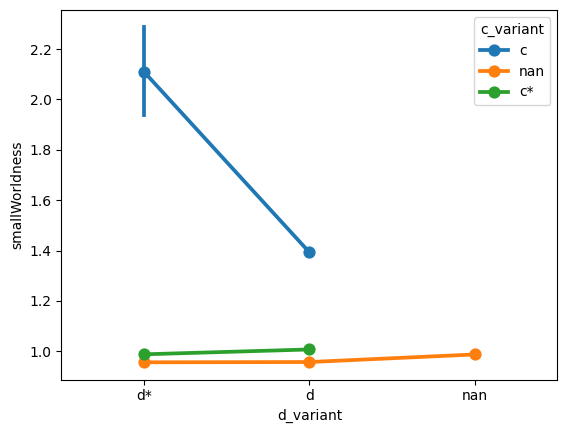

In [ ]:
sns.pointplot(x='d_variant', y='smallWorldness', hue='c_variant', data=final_df)

In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'smallWorldness', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'smallWorldness', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'smallWorldness', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=1.393 mean=1.393

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=1.006 mean=1.007

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.9571 mean=0.9569

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=6.858, p=0.0324
Group sizes & medians:
  w_variant=w          n=20   median=1.763 mean=1.726
  w_variant=w!         n=20   median=1.839 mean=2.171
  w_variant=w*         n=20   median=2.238 mean=2.432
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=161.0, p_raw=0.298, p_adj=0.655, sig=no, Median: w 1.763 < w! 1.839
  w vs w*: U=98.0, p_raw=0.00604, p_adj=0.0242, sig=YES, Median: w 1.763 < w* 2.238
  w! vs w*: U=154.0, p_raw=0.218, p_adj=0.655, sig=no, Median: w! 1.839 < w* 2.238

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=39.518, p=2.62e-09
Group sizes & median

In [ ]:
anova_results = rank_based_anova(final_df, 'assortivity')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),1.146714e-09,2.0,5.568247e-13,1.000000e+00
C(d_variant),1.170109e+05,1.0,1.136370e+02,3.674350e-20
C(c_variant),3.066421e-10,1.0,2.978003e-13,9.999996e-01
C(w_variant):C(d_variant),2.734307e+05,2.0,1.327732e+02,4.431446e-34
C(w_variant):C(c_variant),1.072932e+04,2.0,5.209972e+00,2.384465e-02
C(d_variant):C(c_variant),7.816233e+01,1.0,7.590857e-02,7.832947e-01
C(w_variant):C(d_variant):C(c_variant),8.003410e+04,2.0,3.886319e+01,2.333930e-14
Residual,1.565129e+05,152.0,NaN,NaN


In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'assortivity', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'assortivity', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'assortivity', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.2888 mean=0.295

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=-0.04036 mean=-0.04096

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=-0.002089 mean=-0.004919

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=39.010, p=3.38e-09
Group sizes & medians:
  w_variant=w          n=20   median=0.4077 mean=0.4052
  w_variant=w!         n=20   median=-0.1643 mean=-0.1387
  w_variant=w*         n=20   median=-0.1846 mean=-0.1596
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=398.0, p_raw=9.17e-08, p_adj=5.5e-07, sig=YES, Median: w 0.4077 > w! -0.1643
  w vs w*: U=398.0, p_raw=9.17e-08, p_adj=5.5e-07, sig=YES, Median: w 0.4077 > w* -0.1846
  w! vs w*: U=237.0, p_raw=0.323, p_adj=0.437, sig=no, Median: w! -0.1643 > w* -0.1846

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_varia

In [ ]:
anova_results = rank_based_anova(final_df, 'accuracy')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),5.153315e-09,2.0,2.104902e-12,1.000000e+00
C(d_variant),4.668753e+04,1.0,3.813960e+01,5.743156e-09
C(c_variant),2.568476e-09,1.0,2.098218e-12,9.999988e-01
C(w_variant):C(d_variant),1.671441e+05,2.0,6.827101e+01,6.985909e-22
C(w_variant):C(c_variant),8.751874e+04,2.0,3.574755e+01,1.540522e-08
C(d_variant):C(c_variant),7.810850e+04,1.0,6.380776e+01,3.158184e-13
C(w_variant):C(d_variant):C(c_variant),1.204376e+04,2.0,4.919347e+00,8.508500e-03
Residual,1.860666e+05,152.0,NaN,NaN


<Axes: xlabel='w_variant', ylabel='accuracy'>

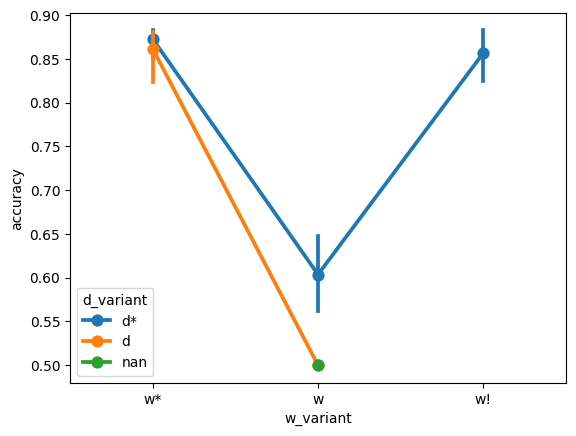

In [ ]:
sns.pointplot(x='w_variant', y='accuracy', hue='d_variant', data=final_df)

In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'accuracy', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'accuracy', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'accuracy', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.5003 mean=0.5004

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=0.8801 mean=0.8615

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.4992 mean=0.4991

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=22.422, p=1.35e-05
Group sizes & medians:
  w_variant=w          n=20   median=0.875 mean=0.8118
  w_variant=w!         n=20   median=0.8856 mean=0.8662
  w_variant=w*         n=20   median=0.8849 mean=0.865
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=49.5, p_raw=4.92e-05, p_adj=0.000197, sig=YES, Median: w 0.875 < w! 0.8856
  w vs w*: U=51.5, p_raw=6.22e-05, p_adj=0.000197, sig=YES, Median: w 0.875 < w* 0.8849
  w! vs w*: U=235.0, p_raw=0.35, p_adj=0.701, sig=no, Median: w! 0.8856 > w* 0.8849

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=39.427, p=2.74e-

In [ ]:
anova_results = rank_based_anova(final_df, 'entropy')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),-5.096411e-11,2.0,-2.147134e-14,1.000000e+00
C(d_variant),7.239310e+04,1.0,6.099888e+01,8.679641e-13
C(c_variant),3.617635e-09,1.0,3.048242e-12,9.999986e-01
C(w_variant):C(d_variant),1.766249e+04,2.0,7.441260e+00,8.258250e-04
C(w_variant):C(c_variant),7.772323e+02,2.0,3.274504e-01,5.680096e-01
C(d_variant):C(c_variant),3.734675e+04,1.0,3.146860e+01,9.329635e-08
C(w_variant):C(d_variant):C(c_variant),1.736861e+04,2.0,7.317448e+00,9.244857e-04
Residual,1.803927e+05,152.0,NaN,NaN


In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'entropy', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'entropy', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'entropy', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.1085 mean=0.5988

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=0.02724 mean=0.02833

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.0554 mean=0.6271

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=39.439, p=2.73e-09
Group sizes & medians:
  w_variant=w          n=20   median=3.996 mean=3.935
  w_variant=w!         n=20   median=1.309 mean=1.258
  w_variant=w*         n=20   median=1.388 mean=1.354
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=400.0, p_raw=6.8e-08, p_adj=2.04e-07, sig=YES, Median: w 3.996 > w! 1.309
  w vs w*: U=400.0, p_raw=6.8e-08, p_adj=2.04e-07, sig=YES, Median: w 3.996 > w* 1.388
  w! vs w*: U=183.0, p_raw=0.655, p_adj=0.655, sig=no, Median: w! 1.309 < w* 1.388

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=0.792, p=0.673
Group 

In [ ]:
anova_results = rank_based_anova(final_df, 'modularity')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),4.695552e-10,2.0,3.275339e-13,1.000000e+00
C(d_variant),9.851030e+03,1.0,1.374299e+01,2.931140e-04
C(c_variant),8.314454e-09,1.0,1.159934e-11,9.999973e-01
C(w_variant):C(d_variant),1.754957e+04,2.0,1.224154e+01,1.176734e-05
C(w_variant):C(c_variant),3.347555e+03,2.0,2.335056e+00,1.285687e-01
C(d_variant):C(c_variant),7.753295e+04,1.0,1.081648e+02,1.812308e-19
C(w_variant):C(d_variant):C(c_variant),1.403693e+04,2.0,9.791328e+00,1.000311e-04
Residual,1.089542e+05,152.0,NaN,NaN


In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'modularity', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'modularity', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'modularity', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.1324 mean=0.132

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=0.08989 mean=0.09062

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.08994 mean=0.08898

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=4.940, p=0.0846
Group sizes & medians:
  w_variant=w          n=20   median=0.5029 mean=0.4937
  w_variant=w!         n=20   median=0.4879 mean=0.4828
  w_variant=w*         n=20   median=0.4747 mean=0.4663

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_variant: H=21.955, p=1.71e-05
Group sizes & medians:
  w_variant=w          n=20   median=0.1232 mean=0.1149
  w_variant=w!         n=20   median=0.08897 mean=0.09541
  w_variant=w*         n=20   median=0.09013 mean=0.09595
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=341.0, p_raw=0.000144, p_adj=0.000289, sig=YES,

In [ ]:
anova_results = rank_based_anova(final_df, 'loss')
anova_results

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 2, but rank is 1
  warnings.warn('covariance of constraints does not have full '


,sum_sq,df,F,PR(>F)
C(w_variant),2.227616e-09,2.0,5.799820e-12,1.000000e+00
C(d_variant),2.597784e+03,1.0,1.352718e+01,3.256997e-04
C(c_variant),4.910276e+05,1.0,2.556879e+03,5.633475e-97
C(w_variant):C(d_variant),9.011908e+04,2.0,2.346340e+02,3.395508e-47
C(w_variant):C(c_variant),2.173153e+05,2.0,5.658023e+02,4.216635e-53
C(d_variant):C(c_variant),7.632026e+03,1.0,3.974149e+01,2.989068e-09
C(w_variant):C(d_variant):C(c_variant),3.625671e+04,2.0,9.439796e+01,2.241500e-27
Residual,2.919035e+04,152.0,NaN,NaN


In [ ]:
print('###### W vs DC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'loss', 'w_variant', ['d_variant', 'c_variant'])
print('\n###### D vs WC ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'loss', 'd_variant', ['w_variant', 'c_variant'])
print('\n###### C vs WD ######')
df_omni, df_pairs = simple_effects_generic(final_df, 'loss', 'c_variant', ['w_variant', 'd_variant'])

###### W vs DC ######

=== d_variant=d, c_variant=c ===
Only one w_variant level present: w
  n=20 median=0.01412 mean=0.0149

=== d_variant=d, c_variant=c* ===
Only one w_variant level present: w*
  n=20 median=0.9906 mean=0.989

=== d_variant=d, c_variant=nan ===
Only one w_variant level present: w
  n=20 median=0.6483 mean=0.6487

=== d_variant=d*, c_variant=c ===
Kruskal–Wallis across w_variant: H=33.352, p=5.72e-08
Group sizes & medians:
  w_variant=w          n=20   median=0.04574 mean=0.04446
  w_variant=w!         n=20   median=0.00167 mean=0.005575
  w_variant=w*         n=20   median=0.002337 mean=0.01132
Pairwise Mann–Whitney (Holm-corrected):
  w vs w!: U=392.0, p_raw=2.22e-07, p_adj=1.33e-06, sig=YES, Median: w 0.04574 > w! 0.00167
  w vs w*: U=373.0, p_raw=3.07e-06, p_adj=1.53e-05, sig=YES, Median: w 0.04574 > w* 0.002337
  w! vs w*: U=167.0, p_raw=0.379, p_adj=0.759, sig=no, Median: w! 0.00167 < w* 0.002337

=== d_variant=d*, c_variant=c* ===
Kruskal–Wallis across w_vari